# Splitting and growth

Run each cell in order after installing COATI. Each training run creates a fresh output directory. Synthetic examples test functionality; they are not biological benchmarks.

## 1. Import

In [1]:
import coati as ct
import numpy as np
import matplotlib.pyplot as plt

## 2. Generate and inspect data

In [2]:
data = ct.datasets.split(n=128, seed=0)
print("Times:", data.times)
print("Primary shapes:", [x.shape for x in data.primary])
print("Secondary shapes:", None if data.secondary is None else [x.shape for x in data.secondary])

Times: [0. 1.]
Primary shapes: [(128, 2), (256, 2)]
Secondary shapes: None


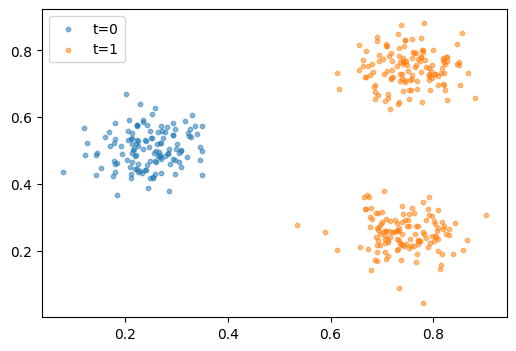

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
for t, x in zip(data.times, data.primary):
    ax.scatter(x[:, 0], x[:, 1], s=10, alpha=.5, label=f"t={t:g}")
ax.legend()
plt.show()

## 3. Choose explicit training settings

In [4]:
config = ct.Config(niters=200, seed=0, unbalancedModel=True, alpha_growth=1., mass_loss=True, mass_coefficient=1.)
config.to_dict()

{'time_plot': False,
 'reverseMatching': False,
 'accumulate_training': True,
 'MixSampling': False,
 'seed': 0,
 'gpu': 0,
 'unbalancedModel': True,
 'alpha_growth': 1.0,
 'mass_loss': True,
 'mass_coefficient': 1.0,
 'global_mass': False,
 'hidden_dim': 64,
 'n_layers': 2,
 'activation': 'leaky_relu',
 'niters': 200,
 'lr': 0.001,
 'num_samples': 64,
 'median_n_sample': 128,
 'floor_n_sample': 64,
 'support_points': False,
 'dt': 0.1,
 'mmd_loss': False,
 'density_coefficient': 0.0,
 'pdf_lossMSE': False,
 'pdf_coefficient': 50.0,
 'sinkhorn_pdf': True,
 'energy_coefficient': 1.0,
 'density_topk': 25,
 'density_hinge': 0.01,
 'terminal_density_weight': 1.0,
 'sync_loss': False,
 'sync_weight': 0.0,
 'sync_mmd_loss': False,
 'sync_density_loss': False,
 'sync_pdf_loss': True,
 'map_type': 'kernel',
 'kernel_sigma': 0.01,
 'adaptive_lambda': False,
 'blur_coeff': 0.05,
 'floor_buffer_std': 0.0,
 'lambda_max_pri': 100.0,
 'lambda_max_sec': 100.0,
 'lambda_min_pri': 5.0,
 'lambda_min_sec

## 4. Train

In [5]:
result = ct.fit(data, config)
print(result.output_dir)

/Users/jingfeng/local/project/COATI/outputs/run-5950a32658


## 5. Integrate trajectories

In [6]:
trajectory = result.predict()
print(trajectory["primary"].shape)
assert np.isfinite(trajectory["primary"]).all()

(41, 128, 2)


## 6. Inspect metrics and trajectories

Energy is in training units; these toy arrays have not been W2-normalized. Endpoint Sinkhorn is an unweighted geometric diagnostic, including in the growth example.

In [7]:
metrics = result.evaluate()
metrics

{'endpoint_sinkhorn_before': 0.1465214043855667,
 'endpoint_sinkhorn_after': 0.0037763561122119427,
 'kinetic_energy_mean': 0.0011688948143273592,
 'endpoint_sampling_floor': 0.0018356784712523222,
 'predicted_mass_ratio': 0.9675921201705933,
 'observed_count_ratio': 2.0}

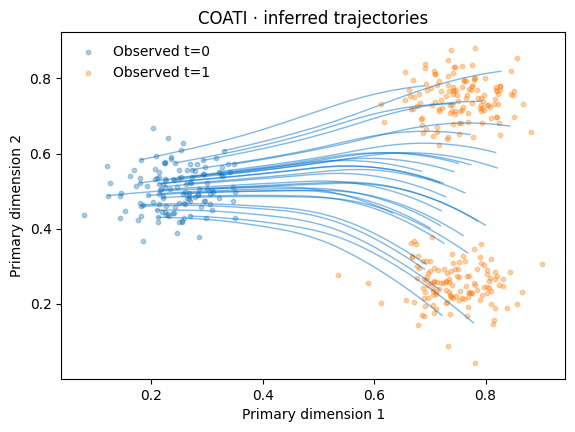

In [8]:
result.plot()
plt.show()

## 7. Reload the saved model

In [9]:
restored = ct.load_result(result.output_dir)
np.testing.assert_array_equal(restored.predict()["primary"], trajectory["primary"])
print("Reload reproduces the trajectory exactly.")

Reload reproduces the trajectory exactly.
